In [6]:
# Cellule 1: Correction - les images sont déjà dans les dossiers
import os
import glob
import shutil

# Les images sont déjà dans ces dossiers
source_dir_1 = '/content/skin_data/HAM10000_images_part_1'
source_dir_2 = '/content/skin_data/HAM10000_images_part_2'

# Créer le dossier cible
os.makedirs('/content/skin_data/images', exist_ok=True)

# Copier les images depuis les dossiers existants
print("Déplacement des images...")

if os.path.exists(source_dir_1) and os.path.isdir(source_dir_1):
    for img in glob.glob(f'{source_dir_1}/*.jpg'):
        shutil.copy(img, '/content/skin_data/images/')
    print(f"✓ Images copiées depuis {source_dir_1}")

if os.path.exists(source_dir_2) and os.path.isdir(source_dir_2):
    for img in glob.glob(f'{source_dir_2}/*.jpg'):
        shutil.copy(img, '/content/skin_data/images/')
    print(f"✓ Images copiées depuis {source_dir_2}")

# Vérification
images = glob.glob('/content/skin_data/images/*.jpg')
print(f"\n✅ {len(images)} images disponibles")

# Afficher les 5 premières
if len(images) > 0:
    print("\nExemples d'images:")
    for img in images[:3]:
        print(f"  - {os.path.basename(img)}")

Déplacement des images...
✓ Images copiées depuis /content/skin_data/HAM10000_images_part_1
✓ Images copiées depuis /content/skin_data/HAM10000_images_part_2

✅ 10015 images disponibles

Exemples d'images:
  - ISIC_0031861.jpg
  - ISIC_0031052.jpg
  - ISIC_0032690.jpg


Using device: cpu
Total images dans metadata: 10015
Images trouvées: 10015 / 10015
Dataset final: 10015 images

📊 Distribution des classes:
  Nævus mélanocytaire (nv): 6705 images (66.9%)
  Mélanome (mel): 1113 images (11.1%)
  Kératose bénigne (bkl): 1099 images (11.0%)
  Carcinome basocellulaire (bcc): 514 images (5.1%)
  Kératose actinique (akiec): 327 images (3.3%)
  Lésions vasculaires (vasc): 142 images (1.4%)
  Dermatofibrome (df): 115 images (1.1%)


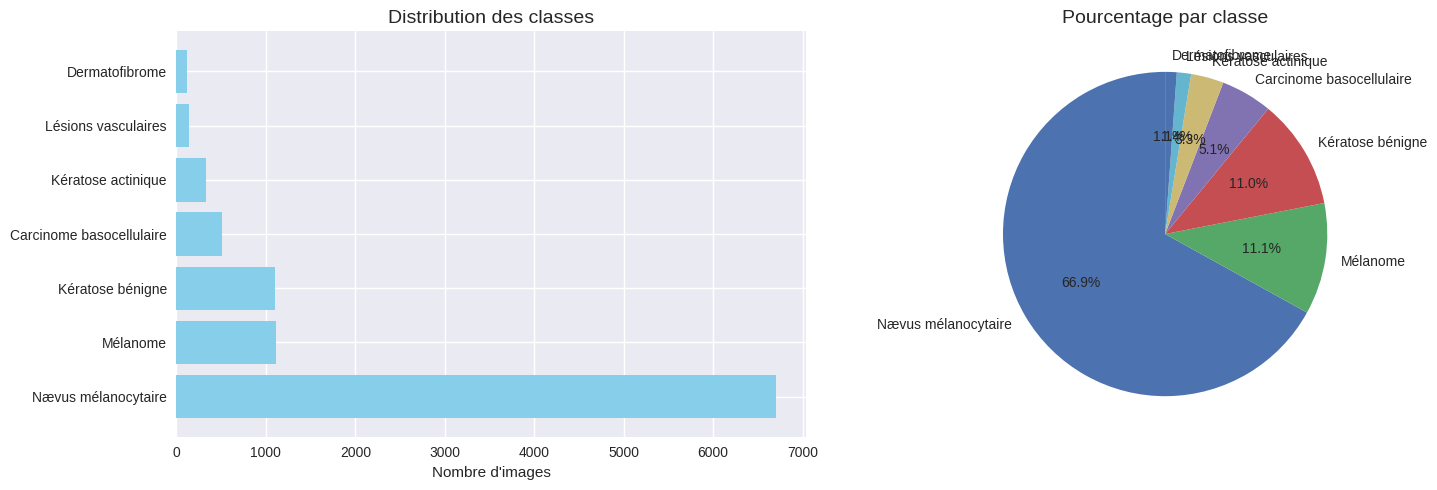

In [7]:
# Cellule 2: Analyse des données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Configuration
plt.style.use('seaborn-v0_8')
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Charger les métadonnées
metadata = pd.read_csv('/content/skin_data/HAM10000_metadata.csv')
print(f"Total images dans metadata: {len(metadata)}")

# Vérifier que toutes les images existent
existing_images = set([os.path.basename(f).replace('.jpg', '') for f in glob.glob('/content/skin_data/images/*.jpg')])
metadata['exists'] = metadata['image_id'].isin(existing_images)
print(f"Images trouvées: {metadata['exists'].sum()} / {len(metadata)}")

# Garder seulement les images qui existent
metadata = metadata[metadata['exists']].reset_index(drop=True)
print(f"Dataset final: {len(metadata)} images")

# Noms des classes en français
class_names_fr = {
    'akiec': 'Kératose actinique',
    'bcc': 'Carcinome basocellulaire',
    'bkl': 'Kératose bénigne',
    'df': 'Dermatofibrome',
    'mel': 'Mélanome',
    'nv': 'Nævus mélanocytaire',
    'vasc': 'Lésions vasculaires'
}

# Distribution
class_counts = metadata['dx'].value_counts()
print("\n📊 Distribution des classes:")
for dx, count in class_counts.items():
    print(f"  {class_names_fr[dx]} ({dx}): {count} images ({count/len(metadata)*100:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(range(len(class_counts)), class_counts.values, color='skyblue')
axes[0].set_yticks(range(len(class_counts)))
axes[0].set_yticklabels([class_names_fr[dx] for dx in class_counts.index])
axes[0].set_title('Distribution des classes', fontsize=14)
axes[0].set_xlabel("Nombre d'images")

axes[1].pie(class_counts.values, labels=[class_names_fr[dx] for dx in class_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Pourcentage par classe', fontsize=14)
plt.tight_layout()
plt.show()

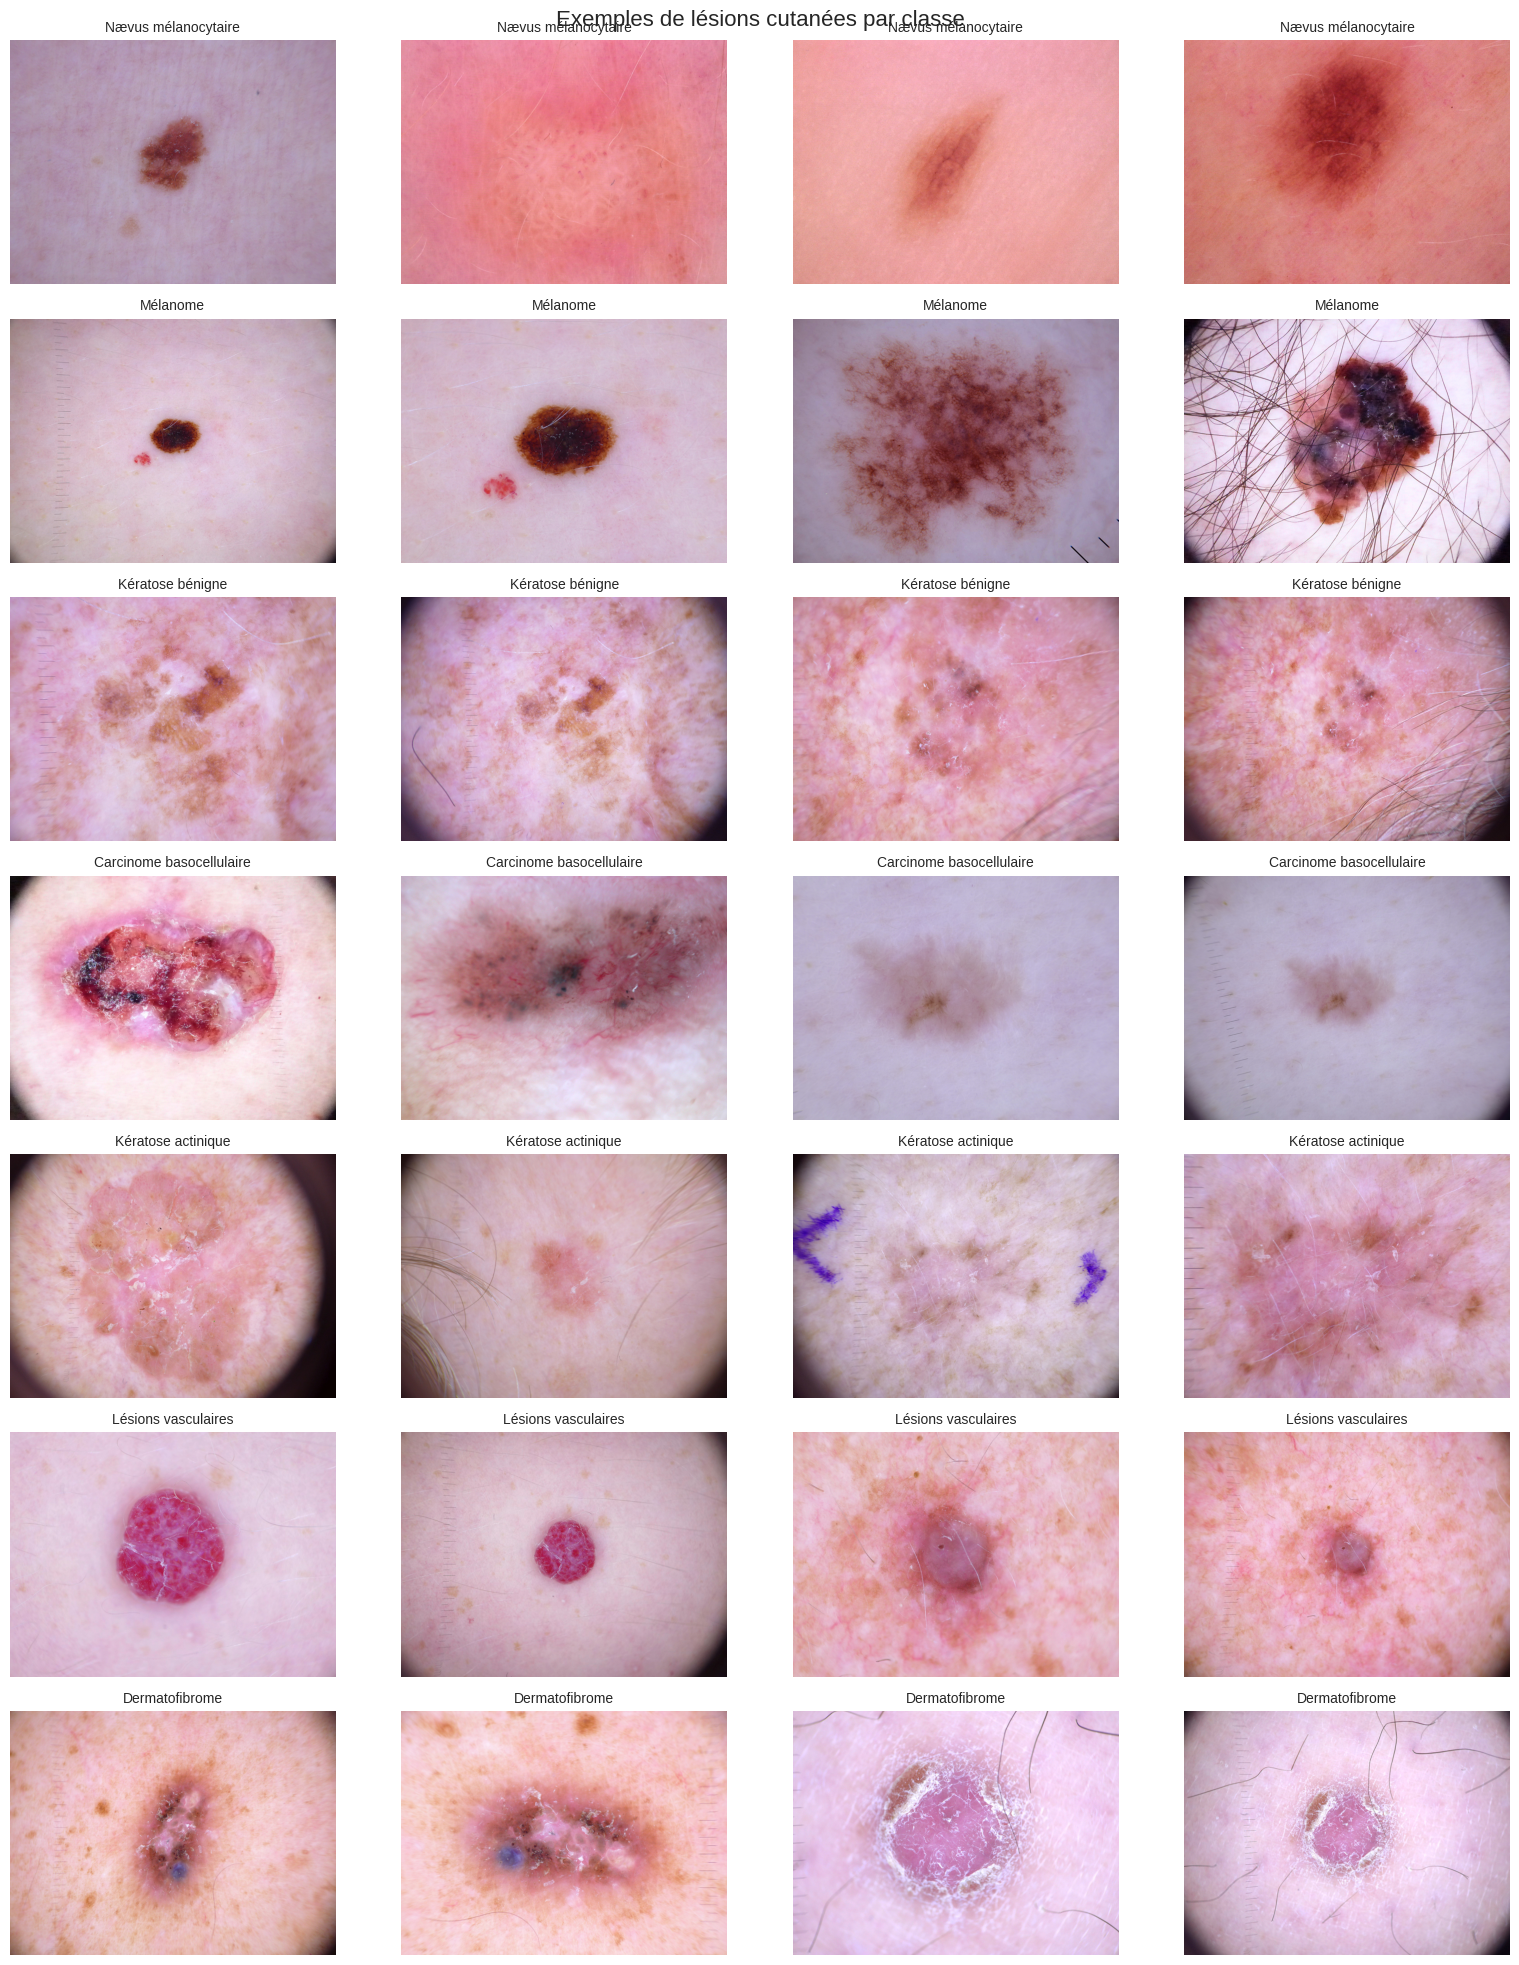

In [8]:
# Cellule 3: Afficher des exemples
fig, axes = plt.subplots(7, 4, figsize=(16, 20))
axes = axes.ravel()

idx = 0
for disease in class_counts.index:
    img_ids = metadata[metadata['dx'] == disease]['image_id'].values[:4]
    for j, img_id in enumerate(img_ids):
        img_path = f"/content/skin_data/images/{img_id}.jpg"
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img)
            axes[idx].set_title(f"{class_names_fr[disease]}", fontsize=10)
            axes[idx].axis('off')
        idx += 1

plt.suptitle('Exemples de lésions cutanées par classe', fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
# Cellule 4: Dataset personnalisé
class SkinLesionDataset(Dataset):
    def __init__(self, metadata, img_dir, transform=None):
        self.metadata = metadata.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform

        # Encoder les labels
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(metadata['dx'])
        self.class_names = self.label_encoder.classes_

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        img_id = self.metadata.loc[idx, 'image_id']
        img_path = self.img_dir / f"{img_id}.jpg"

        image = cv2.imread(str(img_path))
        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Transformations
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Créer le dataset
full_dataset = SkinLesionDataset(
    metadata,
    '/content/skin_data/images',
    transform=train_transform
)

# Split train/val/test (70/15/15)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\n✅ Train: {len(train_dataset)} images")
print(f"✅ Validation: {len(val_dataset)} images")
print(f"✅ Test: {len(test_dataset)} images")
print(f"\nClasses: {list(full_dataset.class_names)}")


✅ Train: 7010 images
✅ Validation: 1502 images
✅ Test: 1503 images

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [10]:
# Cellule: Définition des deux architectures (Simple CNN + ResNet50)
import torch
import torch.nn as nn
from torchvision import models

# 1. DÉFINITION DU SIMPLE CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# 2. DÉFINITION DU RESNET50
class ResNet50SkinCancer(nn.Module):
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super().__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Geler les premières couches
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Dégeler les dernières couches
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

        # Remplacer le classifieur
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

# 3. CRÉATION DES MODÈLES
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
simple_cnn = SimpleCNN(num_classes=7).to(device)
resnet50 = ResNet50SkinCancer(num_classes=7).to(device)

# 4. COMPARAISON
print("="*50)
print("📊 COMPARAISON DES ARCHITECTURES")
print("="*50)

# Compter les paramètres
simple_params = sum(p.numel() for p in simple_cnn.parameters())
simple_trainable = sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad)

resnet_params = sum(p.numel() for p in resnet50.parameters())
resnet_trainable = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)

print(f"\n🔷 SIMPLE CNN:")
print(f"   - Paramètres totaux: {simple_params:,}")
print(f"   - Paramètres entraînables: {simple_trainable:,}")

print(f"\n🔶 RESNET50:")
print(f"   - Paramètres totaux: {resnet_params:,}")
print(f"   - Paramètres entraînables: {resnet_trainable:,} ({resnet_trainable/resnet_params*100:.1f}%)")

print(f"\n✅ Modèles prêts à l'entraînement!")

📊 COMPARAISON DES ARCHITECTURES

🔷 SIMPLE CNN:
   - Paramètres totaux: 423,175
   - Paramètres entraînables: 423,175

🔶 RESNET50:
   - Paramètres totaux: 24,691,783
   - Paramètres entraînables: 16,148,487 (65.4%)

✅ Modèles prêts à l'entraînement!


In [11]:
# Cellule 5: Architecture ResNet50
class ResNet50SkinCancer(nn.Module):
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super().__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Geler les premières couches
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Dégeler les dernières couches
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

        # Remplacer le classifieur
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

model = ResNet50SkinCancer(num_classes=7).to(device)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

Total parameters: 24,691,783
Trainable parameters: 16,148,487 (65.4%)


 COMPARAISON DES PERFORMANCES: SIMPLE CNN vs RESNET50

 ENTRAÎNEMENT SIMPLE CNN

Epoch 1/4
LR: 0.001000


Validation CNN: 100%|██████████| 47/47 [02:17<00:00,  2.92s/it]


Train Loss: 1.8073, Train Acc: 42.54%
Val Loss: 1.6364, Val Acc: 49.13%
✓ Nouveau best Simple CNN! Acc: 49.13%

Epoch 2/4
LR: 0.001000


Validation CNN: 100%|██████████| 47/47 [02:12<00:00,  2.83s/it]


Train Loss: 1.6871, Train Acc: 42.41%
Val Loss: 1.6692, Val Acc: 48.20%

Epoch 3/4
LR: 0.001000


...

Train Loss: 1.1481, Train Acc: 58.93%
Val Loss: 0.9720, Val Acc: 59.32%
✓ Nouveau best ResNet50! Acc: 59.32%

Epoch 3/4
LR: 0.000100


Validation ResNet: 100%|██████████| 47/47 [06:45<00:00,  8.62s/it]


Train Loss: 0.9059, Train Acc: 64.74%
Val Loss: 0.9008, Val Acc: 66.18%
✓ Nouveau best ResNet50! Acc: 66.18%

Epoch 4/4
LR: 0.000100


Validation ResNet: 100%|██████████| 47/47 [06:44<00:00,  8.61s/it]


Train Loss: 0.8497, Train Acc: 66.83%
Val Loss: 0.9478, Val Acc: 68.58%
✓ Nouveau best ResNet50! Acc: 68.58%

📈 COURBES COMPARATIVES


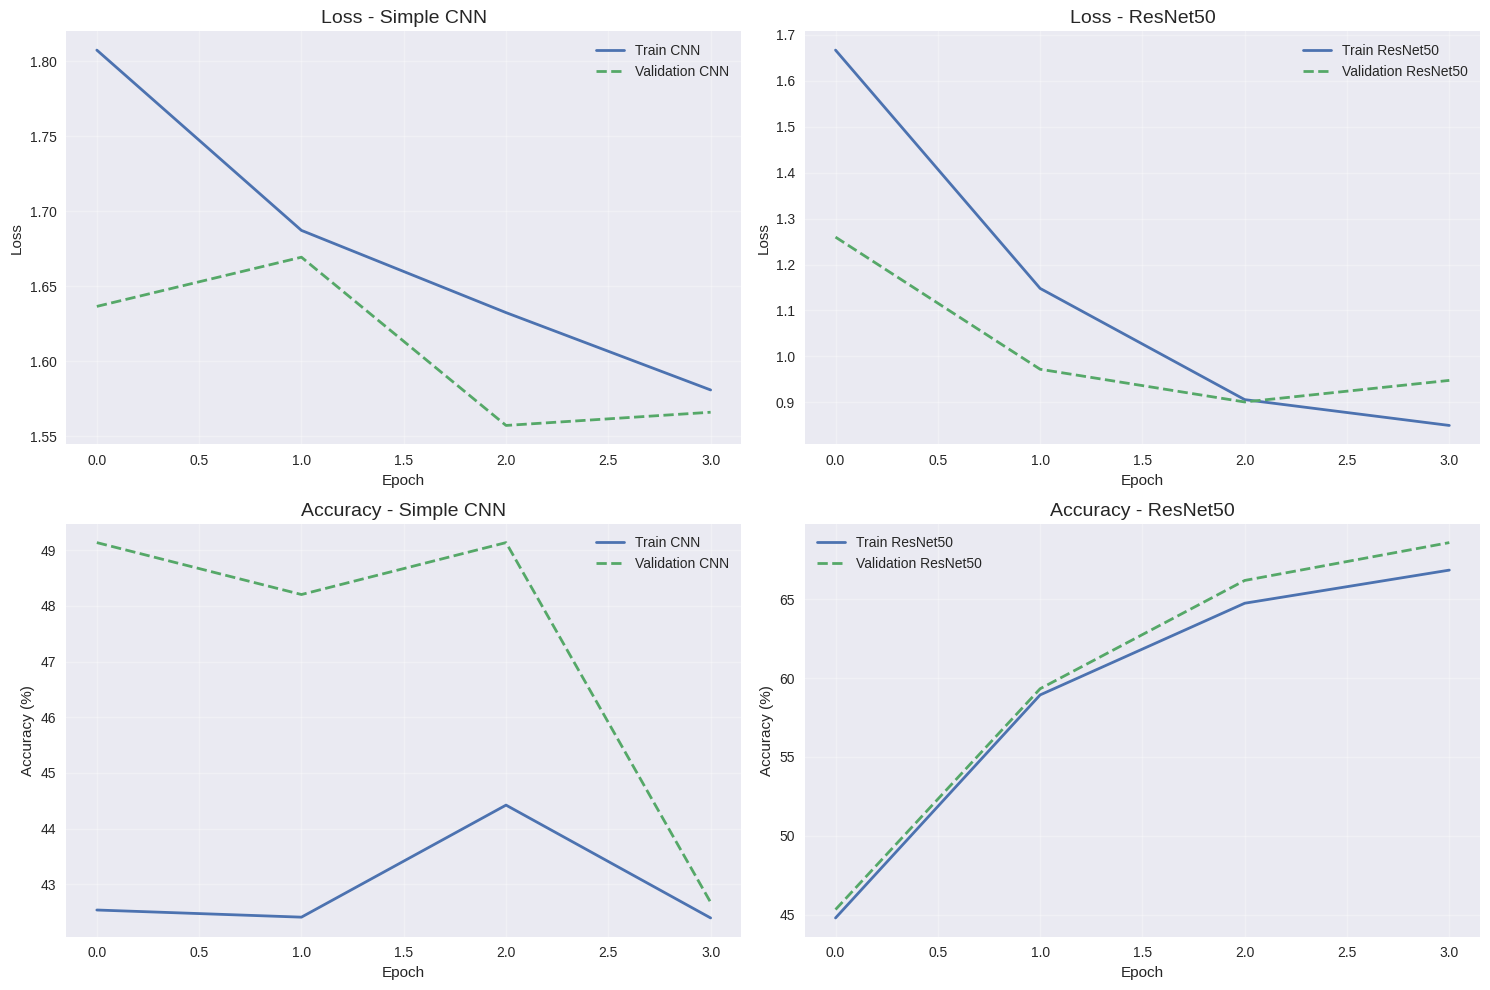


 COMPARAISON FINALE DES MODÈLES
    Modèle Meilleure Accuracy Validation Paramètres totaux Paramètres entraînables
Simple CNN                        49.13%           423,175                 423,175
  ResNet50                        68.58%        24,691,783              16,148,487


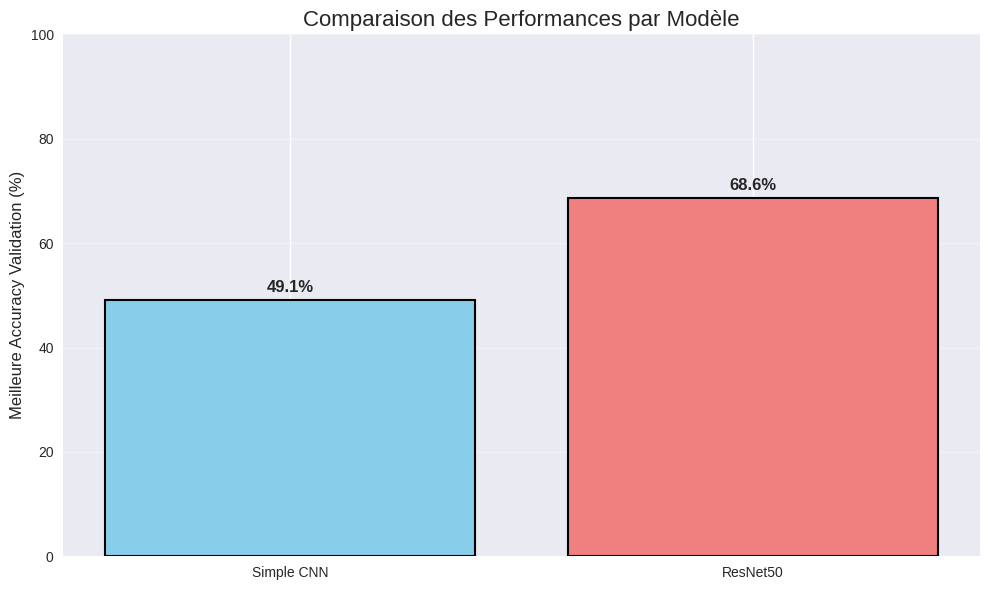


 CONCLUSION
 ResNet50 est meilleur que Simple CNN de 19.44%
   Raisons possibles:
   - Transfer learning (pré-entraînement sur ImageNet)
   - Architecture plus profonde (50 couches vs 4)
   - Skip connections (meilleure propagation du gradient)

 Résultats de comparaison sauvegardés dans 'comparison_results.pkl'


In [13]:
# Cellule 6.5: Entraînement et comparaison des deux modèles
print("="*60)
print(" COMPARAISON DES PERFORMANCES: SIMPLE CNN vs RESNET50")
print("="*60)

# Variables pour stocker les meilleures accuracies
best_acc_cnn = 0
best_acc_resnet = 0

# ============================================
# PARTIE 1: ENTRAÎNEMENT DU SIMPLE CNN
# ============================================
print("\n" + "="*50)
print(" ENTRAÎNEMENT SIMPLE CNN")
print("="*50)

# Hyperparamètres pour Simple CNN
criterion_cnn = nn.CrossEntropyLoss(weight=class_weights)
optimizer_cnn = optim.AdamW(simple_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_cnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode='min', patience=3, factor=0.5)

# Early stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

early_stopping_cnn = EarlyStopping(patience=5)

# Entraînement Simple CNN
num_epochs_cnn = 4
train_losses_cnn, train_accs_cnn = [], []
val_losses_cnn, val_accs_cnn = [], []

for epoch in range(num_epochs_cnn):
    print(f"\nEpoch {epoch+1}/{num_epochs_cnn}")
    print(f"LR: {optimizer_cnn.param_groups[0]['lr']:.6f}")

    # Training
    simple_cnn.train()
    train_loss, train_correct = 0, 0

    for images, labels in tqdm(train_loader, desc='Training CNN'):
        images, labels = images.to(device), labels.to(device)
        optimizer_cnn.zero_grad()
        outputs = simple_cnn(images)
        loss = criterion_cnn(outputs, labels)
        loss.backward()
        optimizer_cnn.step()

        train_loss += loss.item()
        _, preds = outputs.max(1)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / len(train_dataset)
    train_losses_cnn.append(train_loss)
    train_accs_cnn.append(train_acc)

    # Validation
    simple_cnn.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation CNN'):
            images, labels = images.to(device), labels.to(device)
            outputs = simple_cnn(images)
            loss = criterion_cnn(outputs, labels)
            val_loss += loss.item()
            _, preds = outputs.max(1)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / len(val_dataset)
    val_losses_cnn.append(val_loss)
    val_accs_cnn.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Sauvegarder meilleur modèle
    if val_acc > best_acc_cnn:
        best_acc_cnn = val_acc
        torch.save(simple_cnn.state_dict(), 'best_simple_cnn.pth')
        print(f"✓ Nouveau best Simple CNN! Acc: {val_acc:.2f}%")

    scheduler_cnn.step(val_loss)
    early_stopping_cnn(val_loss)
    if early_stopping_cnn.early_stop:
        print(f"Early stopping à l'epoch {epoch+1}")
        break

# ============================================
# PARTIE 2: ENTRAÎNEMENT DU RESNET50
# ============================================
print("\n" + "="*50)
print(" ENTRAÎNEMENT RESNET50")
print("="*50)

# Hyperparamètres pour ResNet50
criterion_resnet = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet = optim.AdamW(resnet50.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='min', patience=3, factor=0.5)
early_stopping_resnet = EarlyStopping(patience=5)

# Entraînement ResNet50
num_epochs_resnet = 4
train_losses_resnet, train_accs_resnet = [], []
val_losses_resnet, val_accs_resnet = [], []

for epoch in range(num_epochs_resnet):
    print(f"\nEpoch {epoch+1}/{num_epochs_resnet}")
    print(f"LR: {optimizer_resnet.param_groups[0]['lr']:.6f}")

    # Training
    resnet50.train()
    train_loss, train_correct = 0, 0

    for images, labels in tqdm(train_loader, desc='Training ResNet'):
        images, labels = images.to(device), labels.to(device)
        optimizer_resnet.zero_grad()
        outputs = resnet50(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        train_loss += loss.item()
        _, preds = outputs.max(1)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / len(train_dataset)
    train_losses_resnet.append(train_loss)
    train_accs_resnet.append(train_acc)

    # Validation
    resnet50.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation ResNet'):
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            loss = criterion_resnet(outputs, labels)
            val_loss += loss.item()
            _, preds = outputs.max(1)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / len(val_dataset)
    val_losses_resnet.append(val_loss)
    val_accs_resnet.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Sauvegarder meilleur modèle
    if val_acc > best_acc_resnet:
        best_acc_resnet = val_acc
        torch.save(resnet50.state_dict(), 'best_resnet50.pth')
        print(f"✓ Nouveau best ResNet50! Acc: {val_acc:.2f}%")

    scheduler_resnet.step(val_loss)
    early_stopping_resnet(val_loss)
    if early_stopping_resnet.early_stop:
        print(f"Early stopping à l'epoch {epoch+1}")
        break

# ============================================
# PARTIE 3: VISUALISATION COMPARATIVE
# ============================================
print("\n" + "="*50)
print("📈 COURBES COMPARATIVES")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(train_losses_cnn, label='Train CNN', linewidth=2)
axes[0, 0].plot(val_losses_cnn, label='Validation CNN', linewidth=2, linestyle='--')
axes[0, 0].set_title('Loss - Simple CNN', fontsize=14)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(train_losses_resnet, label='Train ResNet50', linewidth=2)
axes[0, 1].plot(val_losses_resnet, label='Validation ResNet50', linewidth=2, linestyle='--')
axes[0, 1].set_title('Loss - ResNet50', fontsize=14)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy curves
axes[1, 0].plot(train_accs_cnn, label='Train CNN', linewidth=2)
axes[1, 0].plot(val_accs_cnn, label='Validation CNN', linewidth=2, linestyle='--')
axes[1, 0].set_title('Accuracy - Simple CNN', fontsize=14)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(train_accs_resnet, label='Train ResNet50', linewidth=2)
axes[1, 1].plot(val_accs_resnet, label='Validation ResNet50', linewidth=2, linestyle='--')
axes[1, 1].set_title('Accuracy - ResNet50', fontsize=14)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PARTIE 4: COMPARAISON FINALE
# ============================================
print("\n" + "="*50)
print(" COMPARAISON FINALE DES MODÈLES")
print("="*50)

# Tableau comparatif
comparison_data = {
    'Modèle': ['Simple CNN', 'ResNet50'],
    'Meilleure Accuracy Validation': [f"{best_acc_cnn:.2f}%", f"{best_acc_resnet:.2f}%"],
    'Paramètres totaux': [f"{sum(p.numel() for p in simple_cnn.parameters()):,}",
                          f"{sum(p.numel() for p in resnet50.parameters()):,}"],
    'Paramètres entraînables': [f"{sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad):,}",
                                f"{sum(p.numel() for p in resnet50.parameters() if p.requires_grad):,}"]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Graphique comparatif
plt.figure(figsize=(10, 6))
models = ['Simple CNN', 'ResNet50']
accuracies = [best_acc_cnn, best_acc_resnet]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Comparaison des Performances par Modèle', fontsize=16)
plt.ylabel('Meilleure Accuracy Validation (%)', fontsize=12)
plt.ylim(0, 100)

# Ajouter les valeurs sur les barres
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Conclusion
print("\n" + "="*50)
print(" CONCLUSION")
print("="*50)

if best_acc_resnet > best_acc_cnn:
    improvement = best_acc_resnet - best_acc_cnn
    print(f" ResNet50 est meilleur que Simple CNN de {improvement:.2f}%")
    print("   Raisons possibles:")
    print("   - Transfer learning (pré-entraînement sur ImageNet)")
    print("   - Architecture plus profonde (50 couches vs 4)")
    print("   - Skip connections (meilleure propagation du gradient)")
else:
    print(" Simple CNN performe mieux (rare mais possible)")
    print("   Raisons possibles:")
    print("   - Dataset trop petit pour ResNet50")
    print("   - Surapprentissage du gros modèle")

# Sauvegarder les résultats
results = {
    'simple_cnn': {
        'best_accuracy': best_acc_cnn,
        'train_losses': train_losses_cnn,
        'val_losses': val_losses_cnn,
        'train_accs': train_accs_cnn,
        'val_accs': val_accs_cnn
    },
    'resnet50': {
        'best_accuracy': best_acc_resnet,
        'train_losses': train_losses_resnet,
        'val_losses': val_losses_resnet,
        'train_accs': train_accs_resnet,
        'val_accs': val_accs_resnet
    }
}

import pickle
with open('comparison_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("\n Résultats de comparaison sauvegardés dans 'comparison_results.pkl'")


 ÉVALUATION: Simple CNN


Testing Simple CNN: 100%|██████████| 47/47 [02:23<00:00,  3.05s/it]


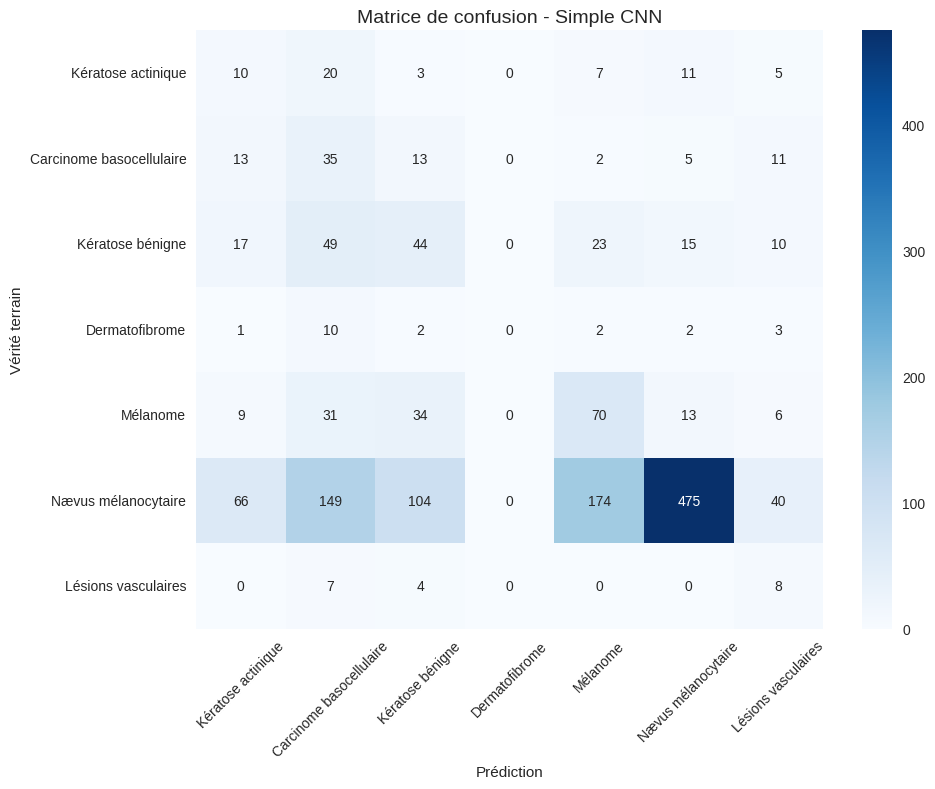


Classification Report - Simple CNN:
                          precision    recall  f1-score   support

      Kératose actinique       0.09      0.18      0.12        56
Carcinome basocellulaire       0.12      0.44      0.18        79
        Kératose bénigne       0.22      0.28      0.24       158
          Dermatofibrome       0.00      0.00      0.00        20
                Mélanome       0.25      0.43      0.32       163
     Nævus mélanocytaire       0.91      0.47      0.62      1008
     Lésions vasculaires       0.10      0.42      0.16        19

                accuracy                           0.43      1503
               macro avg       0.24      0.32      0.23      1503
            weighted avg       0.67      0.43      0.49      1503


 Test Accuracy (Simple CNN): 42.71%

 ÉVALUATION: ResNet50


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Testing ResNet50: 100%|██████████| 47/47 [07:09<0

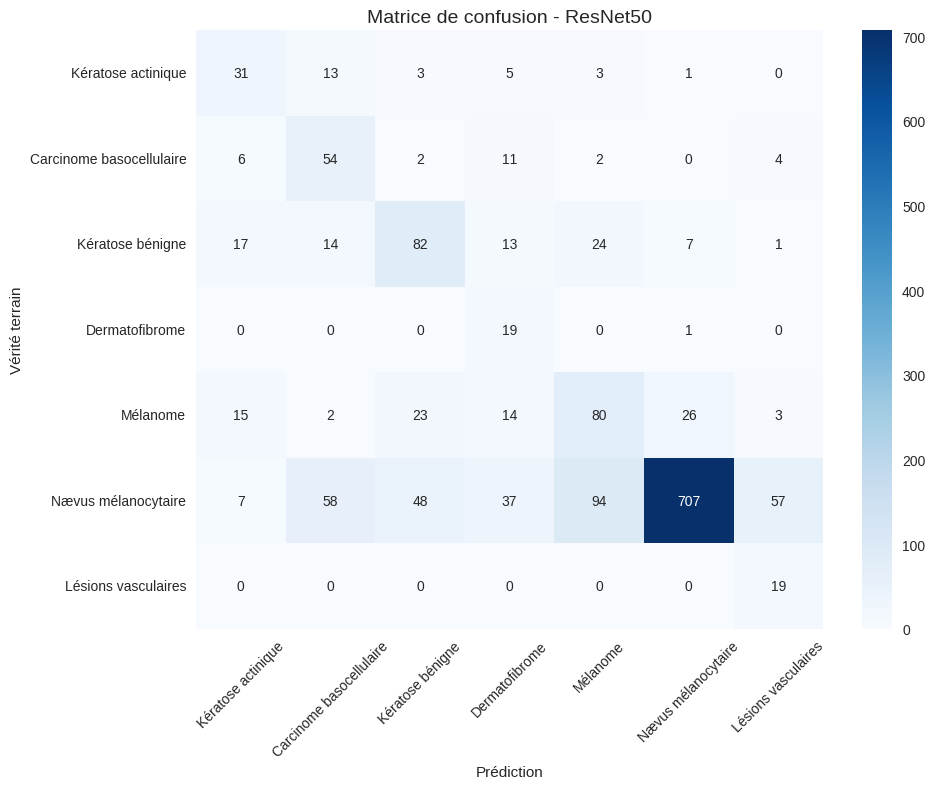


Classification Report - ResNet50:
                          precision    recall  f1-score   support

      Kératose actinique       0.41      0.55      0.47        56
Carcinome basocellulaire       0.38      0.68      0.49        79
        Kératose bénigne       0.52      0.52      0.52       158
          Dermatofibrome       0.19      0.95      0.32        20
                Mélanome       0.39      0.49      0.44       163
     Nævus mélanocytaire       0.95      0.70      0.81      1008
     Lésions vasculaires       0.23      1.00      0.37        19

                accuracy                           0.66      1503
               macro avg       0.44      0.70      0.49      1503
            weighted avg       0.78      0.66      0.70      1503


 Test Accuracy (ResNet50): 66.00%

 MEILLEUR MODÈLE: ResNet50 avec 66.00%


In [14]:
# Cellule 8: Évaluation du meilleur modèle
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

# Charger et évaluer les DEUX modèles
models_to_evaluate = {
    'Simple CNN': simple_cnn,
    'ResNet50': resnet50
}

best_model_name = None
best_test_acc = 0

for model_name, model_instance in models_to_evaluate.items():
    print("\n" + "="*50)
    print(f" ÉVALUATION: {model_name}")
    print("="*50)

    # Charger les meilleurs poids
    if model_name == 'Simple CNN':
        model_instance.load_state_dict(torch.load('best_simple_cnn.pth'))
    else:
        model_instance.load_state_dict(torch.load('best_resnet50.pth'))

    model_instance.eval()
    model_instance = model_instance.to(device)

    all_preds, all_labels_list = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'Testing {model_name}'):
            images = images.to(device)
            outputs = model_instance(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_list.extend(labels.numpy())

    # Matrice de confusion
    cm = confusion_matrix(all_labels_list, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[class_names_fr[c] for c in full_dataset.class_names],
                yticklabels=[class_names_fr[c] for c in full_dataset.class_names])
    plt.title(f'Matrice de confusion - {model_name}', fontsize=14)
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité terrain')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Rapport
    print(f"\nClassification Report - {model_name}:")
    print(classification_report(all_labels_list, all_preds,
                               target_names=[class_names_fr[c] for c in full_dataset.class_names]))

    test_acc = 100 * (np.array(all_preds) == np.array(all_labels_list)).sum() / len(all_labels_list)
    print(f"\n Test Accuracy ({model_name}): {test_acc:.2f}%")

    # Garder le meilleur
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_name = model_name

print("\n" + "="*50)
print(f" MEILLEUR MODÈLE: {best_model_name} avec {best_test_acc:.2f}%")
print("="*50)

In [15]:
# Cellule 9: Sauvegarde du meilleur modèle
import pickle

# Choisir le meilleur modèle
if best_model_name == 'ResNet50':
    best_model = resnet50
    best_model.load_state_dict(torch.load('best_resnet50.pth'))
    model_filename = 'best_resnet50_model.pth'
else:
    best_model = simple_cnn
    best_model.load_state_dict(torch.load('best_simple_cnn.pth'))
    model_filename = 'best_simple_cnn_model.pth'

# Sauvegarder les poids
torch.save(best_model.state_dict(), model_filename)

# Sauvegarder les métadonnées
model_info = {
    'model_name': best_model_name,
    'class_names': list(full_dataset.class_names),
    'class_labels_fr': class_names_fr,
    'input_size': (224, 224),
    'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225],
    'best_val_accuracy': best_acc_resnet if best_model_name == 'ResNet50' else best_acc_cnn,
    'test_accuracy': best_test_acc
}

with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print(f" Meilleur modèle sauvegardé: {model_filename}")
print(f" Métadonnées sauvegardées: model_info.pkl")
print(f" Performance finale: {best_test_acc:.2f}%")

# Télécharger les fichiers
from google.colab import files
files.download(model_filename)
files.download('model_info.pkl')

 Meilleur modèle sauvegardé: best_resnet50_model.pth
 Métadonnées sauvegardées: model_info.pkl
 Performance finale: 66.00%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>